<div style='background: linear-gradient(135deg, #0a0a2e, #3d1278, #7F77DD); padding: 40px; border-radius: 14px; text-align: center; color: white;'>
<h1 style='font-size:2.2em; margin:0 0 8px'>PriceDetection: um novíssimo Detector de Preços</h1>
<h2 style='font-weight:400; color:#c8b8f8; margin:0 0 16px'>Monitoramento de Preços de Supermercado</h2>
<p style='color:#e0d8ff; max-width:600px; margin:0 auto; line-height:1.7'>
Sistema completo com <strong>SQL + Python</strong> para coletar, armazenar e analisar
preços de produtos em supermercados.
</p>
</div>

## Etapa 1: O projeto

| Etapa | O que acontece |
|-------|----------------|
| 1 | Criar o banco SQLite |
| 2 | Popular com produtos, supermercados e histórico de preços |
| 3 | Escrever e executar queries SQL |
| 4 | Funções em Python que consultam o banco |
| 5 | Baixar o `.db` para abrir no DBeaver |


---
## Primeira parte: a criação do Banco de Dados!

In [1]:
# bibliotecas que serão utilizadas
import sqlite3
import pandas as pd
from datetime import date, timedelta
from google.colab import files

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


In [2]:
#conectar ao banco
# No Colab o arquivo fica salvo na sessão atual.
# Ao final do notebook você baixa o .db para abrir no DBeaver.

DB_PATH = 'priceradar.db'
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row   # retorna dicionários
cursor = conn.cursor()

print(f'Conectado ao banco: {DB_PATH}')

Conectado ao banco: priceradar.db


In [3]:
#criar as tabelas (DDL) para fazer consultas posteriormente

schema_sql = '''
DROP TABLE IF EXISTS precos;
DROP TABLE IF EXISTS produtos;
DROP TABLE IF EXISTS supermercados;
DROP TABLE IF EXISTS categorias;

CREATE TABLE categorias (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nome TEXT NOT NULL UNIQUE,
    descricao TEXT
);

CREATE TABLE supermercados (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nome TEXT NOT NULL UNIQUE,
    cidade TEXT NOT NULL,
    bairro TEXT,
    ativo INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE produtos (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nome TEXT NOT NULL,
    marca TEXT,
    unidade TEXT NOT NULL,
    categoria_id INTEGER NOT NULL,
    FOREIGN KEY (categoria_id) REFERENCES categorias(id)
);

CREATE TABLE precos (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    produto_id INTEGER NOT NULL,
    supermercado_id INTEGER NOT NULL,
    preco REAL NOT NULL,
    data_coleta TEXT NOT NULL DEFAULT CURRENT_DATE,
    em_promocao INTEGER NOT NULL DEFAULT 0,
    FOREIGN KEY (produto_id) REFERENCES produtos(id),
    FOREIGN KEY (supermercado_id) REFERENCES supermercados(id)
);

CREATE INDEX idx_precos_produto ON precos(produto_id);
CREATE INDEX idx_precos_mercado ON precos(supermercado_id);
CREATE INDEX idx_precos_data ON precos(data_coleta);
'''

cursor.executescript(schema_sql)
conn.commit()
print('Tabelas criadas: categorias, supermercados, produtos, precos')

Tabelas criadas: categorias, supermercados, produtos, precos


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Diagrama do banco

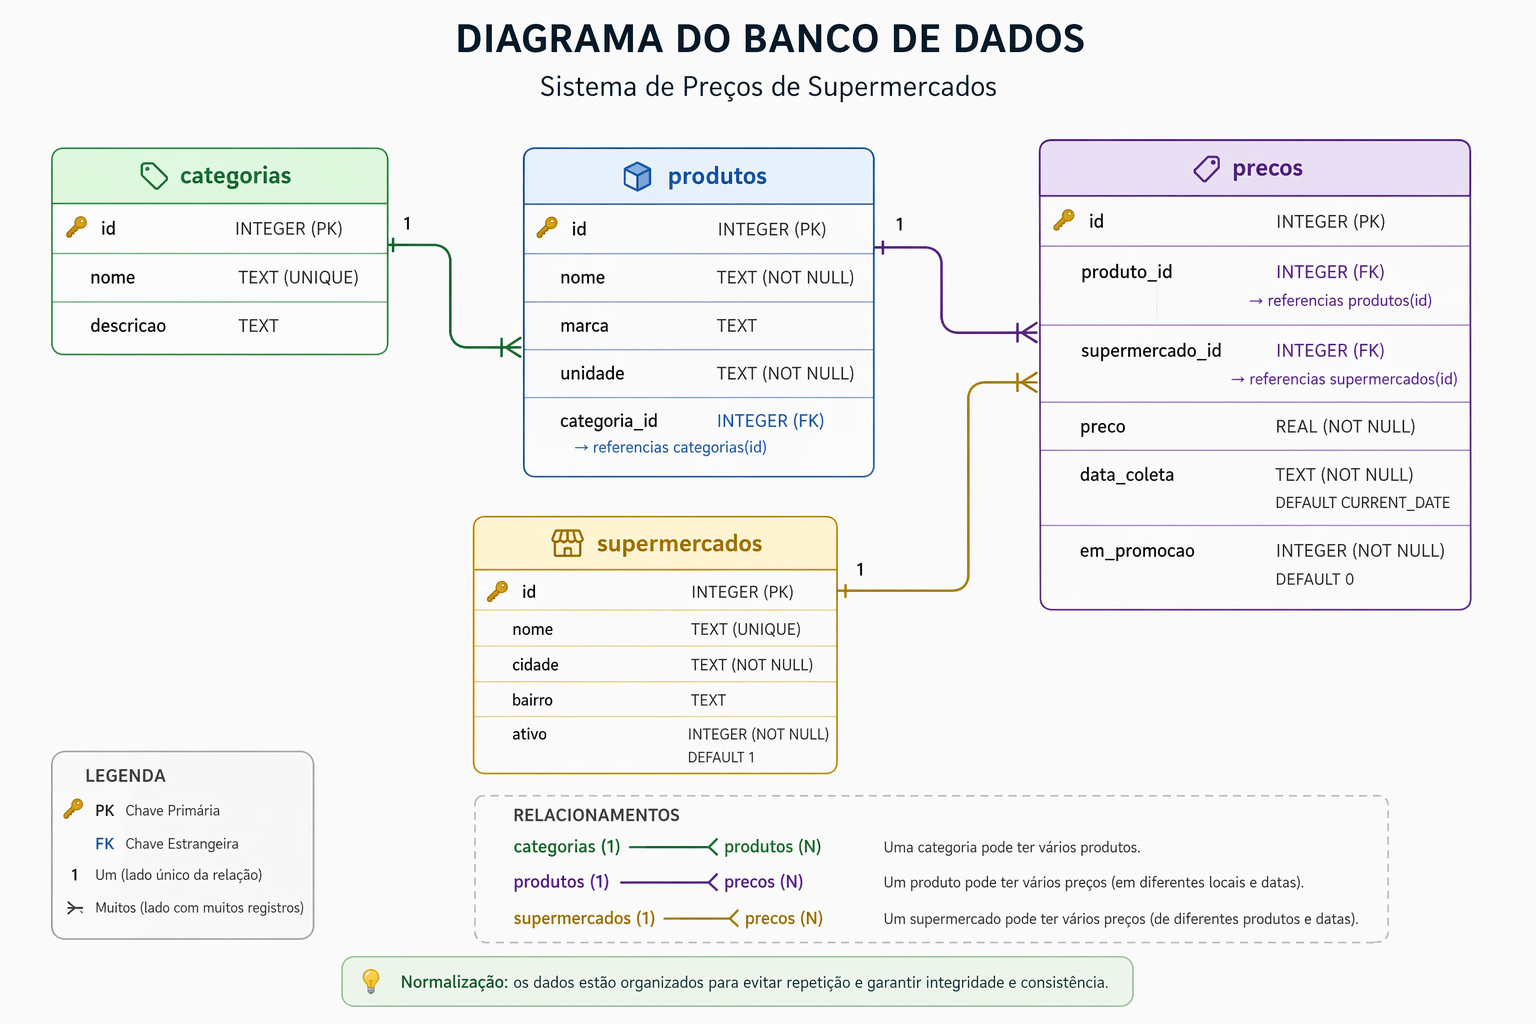

In [7]:
from IPython.display import Image, display

display(Image(filename='/content/drive/MyDrive/Projetos_github/price_radar/diagrama.png'))

**Por que 4 tabelas?** Se você guardasse tudo em uma tabela só, o nome
do supermercado repetiria em cada linha de preço. Com tabelas separadas
você evita repetição e mantém os dados consistentes.

In [ ]:
#Inserção de dados nas tabelas - categorias (DML)

cursor.executemany(
    'INSERT INTO categorias (nome, descricao) VALUES (?, ?)',
    [
        ('Grãos e Cereais',  'Arroz, feijão, macarrão...'),
        ('Óleos e Gorduras', 'Óleos vegetais, azeite...'),
        ('Laticínios',       'Leite, queijo, manteiga...'),
        ('Carnes',           'Frango, bovina, suína...'),
        ('Higiene Pessoal',  'Shampoo, sabonete...'),
        ('Limpeza',          'Detergente, sabão em pó...'),
    ]
)
conn.commit()

df = pd.read_sql('SELECT * FROM categorias', conn)
print('Categorias inseridas:')
display(df)

In [ ]:
#inserção de dados: supermercados de Uberlândia

cursor.executemany(
    'INSERT INTO supermercados (nome, cidade, bairro) VALUES (?, ?, ?)',
    [
        ('Atacadão',    'Uberlândia', 'Brasil'),
        ('Bretas',      'Uberlândia', 'Centro'),
        ('Superpão',    'Uberlândia', 'Santa Mônica'),
        ('Comper',      'Uberlândia', 'Tibery'),
        ("Sam's Club",  'Uberlândia', 'Jardim Karaíba'),
    ]
)
conn.commit()

df = pd.read_sql('SELECT * FROM supermercados', conn)
print('Supermercados inseridos:')
display(df)

In [ ]:
#produtos

cursor.executemany(
    'INSERT INTO produtos (nome, marca, unidade, categoria_id) VALUES (?, ?, ?, ?)',
    [
        # Grãos (cat 1)
        ('Arroz Branco',       'Tio João',  '5kg',   1),
        ('Arroz Branco',       'Camil',     '5kg',   1),
        ('Feijão Carioca',     'Camil',     '1kg',   1),
        ('Feijão Preto',       'Kicaldo',   '1kg',   1),
        ('Macarrão Espaguete', 'Barilla',   '500g',  1),
        # Óleos (cat 2)
        ('Óleo de Soja',       'Liza',      '900ml', 2),
        ('Azeite Extra Virgem','Galo',      '500ml', 2),
        # Laticínios (cat 3)
        ('Leite Integral',     'Itambé',    '1L',    3),
        ('Queijo Mussarela',   'Polenghi',  '500g',  3),
        ('Manteiga',           'Aviação',   '200g',  3),
        # Carnes (cat 4)
        ('Peito de Frango',    'Sadia',     '1kg',   4),
        ('Patinho Moído',      'Friboi',    '500g',  4),
        # Higiene (cat 5)
        ('Shampoo',            'Pantene',   '400ml', 5),
        ('Sabonete',           'Dove',      '90g',   5),
        # Limpeza (cat 6)
        ('Detergente',         'Ypê',       '500ml', 6),
        ('Sabão em Pó',        'OMO',       '1kg',   6),
    ]
)
conn.commit()

df = pd.read_sql('SELECT p.*, c.nome as categoria FROM produtos p JOIN categorias c ON c.id=p.categoria_id', conn)
print(f'{len(df)} produtos inseridos:')
display(df)

In [ ]:
# histórico de preços inseridos;
# cada produto em cada supermercado, com variação

hoje = date.today()

# Tabela base: produto_id, supermercado_id, preco_base
precos_base = [
    # Arroz Tio João
    (1, 1, 22.90), (1, 2, 24.99), (1, 3, 23.50), (1, 4, 25.90), (1, 5, 21.99),
    # Arroz Camil
    (2, 1, 21.99), (2, 2, 23.50), (2, 3, 22.90), (2, 4, 24.50), (2, 5, 20.99),
    # Feijão Carioca
    (3, 1,  7.90), (3, 2,  8.99), (3, 3,  8.50), (3, 4,  9.20), (3, 5,  7.50),
    # Feijão Preto
    (4, 1,  8.50), (4, 2,  9.49), (4, 3,  8.90), (4, 4,  9.90), (4, 5,  8.20),
    # Óleo de Soja
    (6, 1,  5.90), (6, 2,  6.49), (6, 3,  6.20), (6, 4,  6.99), (6, 5,  5.79),
    # Leite Integral
    (8, 1,  4.29), (8, 2,  4.79), (8, 3,  4.50), (8, 4,  4.99), (8, 5,  4.19),
    # Peito de Frango
    (11, 1, 14.90),(11, 2, 16.99),(11, 3, 15.50),(11, 4, 17.90),(11, 5, 13.99),
    # Detergente
    (15, 1,  2.29),(15, 2,  2.79),(15, 3,  2.50),(15, 4,  2.99),(15, 5,  2.19),
]

import random
random.seed(42)

registros = []
for dias_atras in range(6, -1, -1):  # 6 dias atrás até hoje
    data_coleta = (hoje - timedelta(days=dias_atras)).isoformat()
    for produto_id, mercado_id, preco_base in precos_base:
        # Variação aleatória pequena (±3%) para simular oscilação real
        variacao = random.uniform(-0.03, 0.03)
        preco    = round(preco_base * (1 + variacao), 2)
        # Promoção no último dia em alguns produtos no Sam's Club (id=5)
        em_promo = 1 if (dias_atras == 0 and mercado_id == 5 and produto_id in [1, 6, 15]) else 0
        if em_promo:
            preco = round(preco * 0.90, 2)  # 10% de desconto na promoção
        registros.append((produto_id, mercado_id, preco, data_coleta, em_promo))

cursor.executemany(
    'INSERT INTO precos (produto_id, supermercado_id, preco, data_coleta, em_promocao) VALUES (?,?,?,?,?)',
    registros
)
conn.commit()

total = cursor.execute('SELECT COUNT(*) FROM precos').fetchone()[0]
print(f'{total} registros de preço inseridos ({len(precos_base)} combos × 7 dias)')

---
## Segunda parte: Queries

In [ ]:
#Query 1: Menor preço de cada produto hoje
print('Menor preço de cada produto hoje:')

q1 = '''
SELECT
    p.nome AS produto,
    p.unidade,
    c.nome AS categoria,
    s.nome AS mercado_mais_barato,
    ROUND(MIN(pr.preco), 2) AS menor_preco,
    ROUND(MAX(pr.preco), 2) AS maior_preco,
    ROUND(AVG(pr.preco), 2) AS preco_medio
FROM precos pr
JOIN produtos p ON p.id = pr.produto_id
JOIN supermercados s ON s.id = pr.supermercado_id
JOIN categorias c ON c.id = p.categoria_id
WHERE pr.data_coleta = DATE('now')
GROUP BY p.id
ORDER BY c.nome, p.nome
'''

df1 = pd.read_sql(q1, conn)
display(df1)

In [ ]:
#Query 2: Ranking de supermercados para uma lista de compras
print('Onde fica mais barato comprar minha lista?')

q2 = '''
SELECT
    s.nome AS supermercado,
    COUNT(DISTINCT pr.produto_id) AS produtos_encontrados,
    ROUND(SUM(pr.preco), 2) AS total_lista,
    ROUND(AVG(pr.preco), 2) AS ticket_medio
FROM precos pr
JOIN supermercados s ON s.id = pr.supermercado_id
JOIN produtos p ON p.id = pr.produto_id
WHERE pr.data_coleta = DATE('now')
  AND p.nome IN ('Arroz Branco', 'Feijão Carioca', 'Óleo de Soja', 'Leite Integral')
GROUP BY s.id
ORDER BY total_lista ASC
'''

df2 = pd.read_sql(q2, conn)
display(df2)

mais_barato  = df2.iloc[0]
mais_caro    = df2.iloc[-1]
economia     = mais_caro['total_lista'] - mais_barato['total_lista']
print(f'\nVocê economiza R$ {economia:.2f} comprando no {mais_barato["supermercado"]} em vez do {mais_caro["supermercado"]}')

In [ ]:
#Query 3: Histórico de preços com variação diária
print('Histórico do Arroz Tio João - variação diária:')

q3 = '''
SELECT
    pr.data_coleta,
    s.nome   AS supermercado,
    pr.preco,
    ROUND(
        pr.preco - LAG(pr.preco) OVER (
            PARTITION BY pr.supermercado_id
            ORDER BY pr.data_coleta
        ), 2
    ) AS variacao_dia
FROM precos pr
JOIN supermercados s ON s.id = pr.supermercado_id
JOIN produtos p ON p.id = pr.produto_id
WHERE p.nome = 'Arroz Branco'
  AND p.marca = 'Tio João'
ORDER BY pr.data_coleta, s.nome
'''

df3 = pd.read_sql(q3, conn)
display(df3)

In [ ]:
#Query 4: Detecção de promoções
print('Promoções detectadas hoje (queda > 5%):')

q4 = '''
WITH historico AS (
    SELECT
        produto_id,
        supermercado_id,
        preco,
        data_coleta,
        LAG(preco) OVER (
            PARTITION BY produto_id, supermercado_id
            ORDER BY data_coleta
        ) AS preco_anterior
    FROM precos
)
SELECT
    p.nome AS produto,
    p.unidade,
    s.nome AS supermercado,
    ROUND(h.preco_anterior, 2) AS preco_antes,
    ROUND(h.preco, 2) AS preco_agora,
    ROUND(
        (h.preco - h.preco_anterior) * 100.0 / h.preco_anterior,
    2)             AS variacao_pct
FROM historico h
JOIN produtos p ON p.id = h.produto_id
JOIN supermercados s ON s.id = h.supermercado_id
WHERE h.preco_anterior IS NOT NULL
  AND h.preco < h.preco_anterior * 0.95
  AND h.data_coleta = DATE('now')
ORDER BY variacao_pct ASC
'''

df4 = pd.read_sql(q4, conn)
if len(df4) > 0:
    display(df4)
else:
    print('Nenhuma promoção detectada hoje.')

In [ ]:
#Query 5: Onde comprar faz mais diferença?
print('Produtos com maior variação de preço entre supermercados:')

q5 = '''
SELECT
    p.nome AS produto,
    p.unidade,
    ROUND(MIN(pr.preco), 2) AS preco_min,
    ROUND(MAX(pr.preco), 2) AS preco_max,
    ROUND(MAX(pr.preco) - MIN(pr.preco), 2) AS diferenca_R$,
    ROUND(
        (MAX(pr.preco) - MIN(pr.preco)) * 100.0 / MIN(pr.preco), 1) AS diferenca_pct
FROM precos pr
JOIN produtos p ON p.id = pr.produto_id
WHERE pr.data_coleta = DATE('now')
GROUP BY p.id
HAVING COUNT(DISTINCT pr.supermercado_id) >= 3
ORDER BY diferenca_pct DESC
'''

df5 = pd.read_sql(q5, conn)
display(df5)

In [ ]:
# ── Query 6: Ranking geral de supermercados ────────────────────────────────
print('Reputação de preço por supermercado (histórico completo):')

q6 = '''
SELECT
    s.nome AS supermercado,
    s.bairro,
    COUNT(DISTINCT pr.produto_id) AS produtos_monitorados,
    ROUND(AVG(pr.preco), 2) AS preco_medio,
    ROUND(MIN(pr.preco), 2) AS menor_preco,
    ROUND(MAX(pr.preco), 2) AS maior_preco,
    COUNT(*) AS total_coletas
FROM precos pr
JOIN supermercados s ON s.id = pr.supermercado_id
GROUP BY s.id
ORDER BY preco_medio ASC
'''

df6 = pd.read_sql(q6, conn)
display(df6)

---
## Terceira parte: Funções Python reutilizáveis

In [ ]:
#Funções que encapsulam as queries

def buscar_produto(nome: str) -> pd.DataFrame:
    #Busca produtos pelo nome (parcial)
    return pd.read_sql(
        '''
        SELECT p.id, p.nome, p.marca, p.unidade, c.nome AS categoria
        FROM produtos p
        JOIN categorias c ON c.id = p.categoria_id
        WHERE LOWER(p.nome) LIKE LOWER(?)
        ORDER BY p.nome, p.marca
        ''',
        conn, params=(f'%{nome}%',)
    )


def historico_produto(produto_id: int, dias: int = 7) -> pd.DataFrame:
    #Retorna o histórico de preços de um produto nos últimos x dias
    from datetime import date, timedelta
    data_inicio = (date.today() - timedelta(days=dias)).isoformat()
    return pd.read_sql(
        '''
        SELECT pr.data_coleta, s.nome AS supermercado, pr.preco
        FROM precos pr
        JOIN supermercados s ON s.id = pr.supermercado_id
        WHERE pr.produto_id  = ?
          AND pr.data_coleta >= ?
        ORDER BY pr.data_coleta, s.nome
        ''',
        conn, params=(produto_id, data_inicio)
    )


def ranking_supermercados(lista_produtos: list) -> pd.DataFrame:
    #Qual supermercado é mais barato para comprar a lista?
    placeholders = ','.join(['?'] * len(lista_produtos))
    return pd.read_sql(
        f'''
        SELECT
            s.nome                          AS supermercado,
            COUNT(DISTINCT pr.produto_id)   AS produtos_encontrados,
            ROUND(SUM(pr.preco), 2)         AS total_lista
        FROM precos pr
        JOIN supermercados s ON s.id = pr.supermercado_id
        JOIN produtos      p ON p.id = pr.produto_id
        WHERE pr.data_coleta = DATE('now')
          AND p.nome IN ({placeholders})
        GROUP BY s.id
        ORDER BY total_lista ASC
        ''',
        conn, params=lista_produtos
    )


def detectar_promocoes(queda_pct: float = 5.0) -> pd.DataFrame:
    #Produtos que caíram mais de X% vs o dia anterior.
    return pd.read_sql(
        '''
        WITH h AS (
            SELECT produto_id, supermercado_id, preco, data_coleta,
                   LAG(preco) OVER (
                       PARTITION BY produto_id, supermercado_id
                       ORDER BY data_coleta
                   ) AS preco_anterior
            FROM precos
        )
        SELECT
            p.nome AS produto, p.unidade,
            s.nome AS supermercado,
            ROUND(h.preco_anterior, 2) AS preco_antes,
            ROUND(h.preco, 2) AS preco_agora,
            ROUND((h.preco - h.preco_anterior)*100.0/h.preco_anterior, 2) AS variacao_pct
        FROM h
        JOIN produtos p ON p.id = h.produto_id
        JOIN supermercados s ON s.id = h.supermercado_id
        WHERE h.preco_anterior IS NOT NULL
          AND h.preco < h.preco_anterior * (1 - ? / 100.0)
          AND h.data_coleta = DATE('now')
        ORDER BY variacao_pct ASC
        ''',
        conn, params=(queda_pct,)
    )


print('Funções definidas!')

In [ ]:
#mini-teste de funções!

print('Buscar produto "arroz":')
display(buscar_produto('arroz'))

print('\nHistórico do produto id=1 (últimos 7 dias):')
display(historico_produto(produto_id=1, dias=7))

print('\nRanking: lista de compras:')
lista = ['Arroz Branco', 'Feijão Carioca', 'Óleo de Soja', 'Leite Integral']
display(ranking_supermercados(lista))

print('\nPromoções detectadas (queda > 5%):')
display(detectar_promocoes(5.0))

---
## Quarta parte: Baixar o banco para o DBeaver

In [ ]:
#Salvar e baixar o .db
conn.commit()
conn.close()

#Isso abre o diálogo de download no navegador
files.download('priceradar.db')

print('Banco salvo e pronto para download!')
print('Próximo passo: abra o DBeaver e conecte ao arquivo priceradar.db')

---
## Como abrir no DBeaver e utilizar o banco de dados criado e gerado nesse código! :D

Depois de baixar o `priceradar.db`, siga esses passos no DBeaver:

### 1. Nova conexão
- Menu: **Database → New Database Connection**
- Selecione: **SQLite**
- Clique: **Next**

### 2. Selecionar o arquivo
- Em **Path**, clique em **Browse**
- Navegue até onde você salvou o `priceradar.db`
- Clique em **Finish**

### 3. Explorar o banco
- No painel esquerdo, expanda a conexão
- Expanda **Tables** — você vai ver: `categorias`, `supermercados`, `produtos`, `precos`
- Clique duas vezes em qualquer tabela para ver os dados

### 4. Executar queries
- Clique com botão direito na conexão → **SQL Editor → New SQL Script**
- Cole qualquer uma das queries abaixo e aperte **Ctrl+Enter** para rodar

```sql
-- para ver todos os preços de hoje
SELECT p.nome, s.nome AS mercado, pr.preco, pr.data_coleta
FROM precos pr
JOIN produtos p ON p.id = pr.produto_id
JOIN supermercados s ON s.id = pr.supermercado_id
WHERE pr.data_coleta = DATE('now')
ORDER BY p.nome, pr.preco;

-- supermercado mais barato em média
SELECT s.nome, ROUND(AVG(pr.preco), 2) AS preco_medio
FROM precos pr
JOIN supermercados s ON s.id = pr.supermercado_id
GROUP BY s.id
ORDER BY preco_medio ASC;

-- quanto você economiza escolhendo o mercado certo?
SELECT
    p.nome,
    MIN(pr.preco) AS mais_barato,
    MAX(pr.preco) AS mais_caro,
    ROUND(MAX(pr.preco) - MIN(pr.preco), 2) AS economia
FROM precos pr
JOIN produtos p ON p.id = pr.produto_id
WHERE pr.data_coleta = DATE('now')
GROUP BY p.id
ORDER BY economia DESC;
```